In [1]:
# 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from statsmodels.tsa.holtwinters import ExponentialSmoothing

import warnings
warnings.filterwarnings("ignore")

In [2]:
# 2. LOAD DATASET

df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

DATASET LOADED SUCCESSFULLY

Dataset Shape:
(2640, 12)

First 5 Rows:
   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1 

In [3]:
# 3. DATASET INFORMATION

print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())


DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None

Missing Values:
Year                    0
Month                   0
Region              

In [5]:
# 4. DATA CLEANING

print("DATA CLEANING")


before_rows = df.shape[0]

# Remove duplicates
df.drop_duplicates(inplace=True)

after_rows = df.shape[0]

print(f"Rows Before Cleaning : {before_rows}")
print(f"Rows After Cleaning  : {after_rows}")

DATA CLEANING
Rows Before Cleaning : 2640
Rows After Cleaning  : 2640



EXPLORATORY DATA ANALYSIS


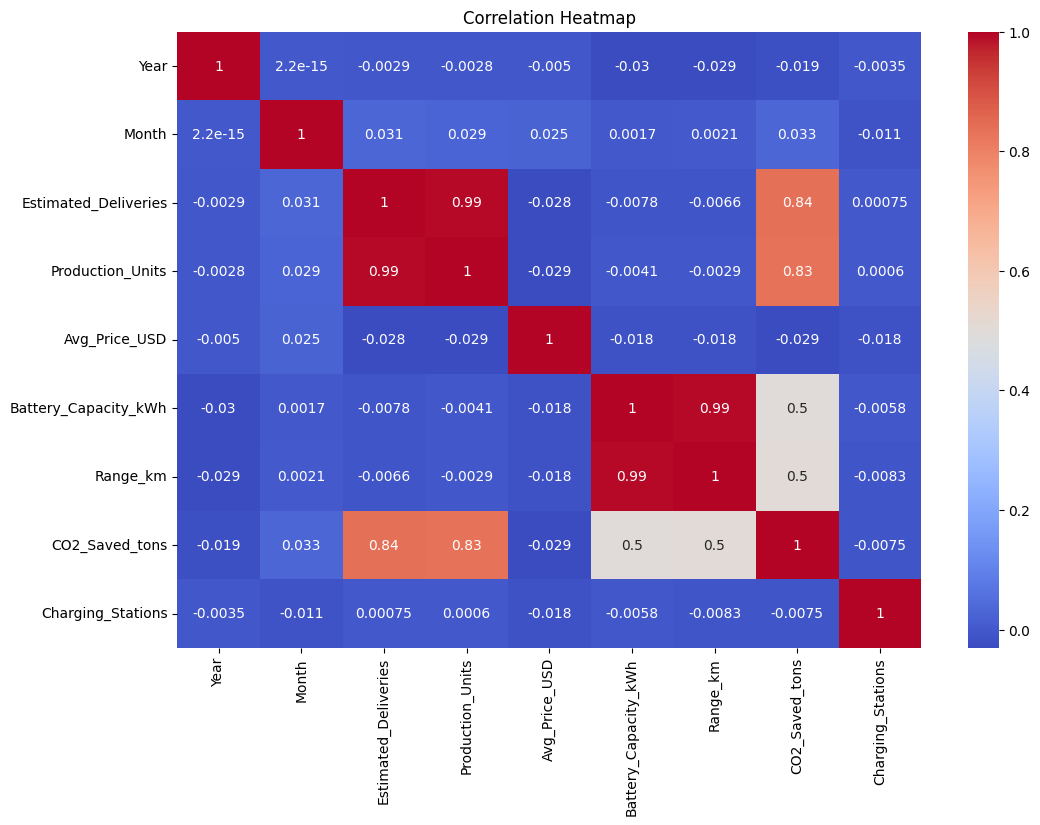

In [6]:
# 5. EXPLORATORY DATA ANALYSIS (EDA)

print("\n" + "=" * 60)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

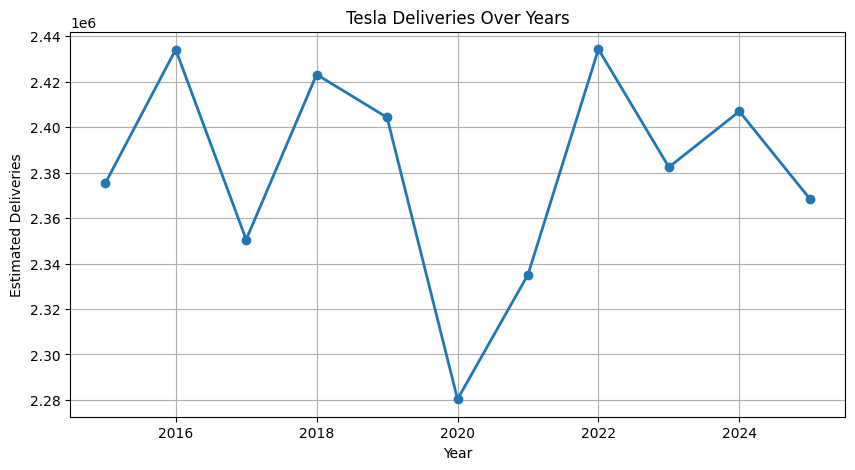

In [7]:
# Yearly Deliveries Trend

yearly_deliveries = df.groupby(
    "Year"
)["Estimated_Deliveries"].sum()

plt.figure(figsize=(10,5))

plt.plot(
    yearly_deliveries.index,
    yearly_deliveries.values,
    marker='o',
    linewidth=2
)

plt.title("Tesla Deliveries Over Years")
plt.xlabel("Year")
plt.ylabel("Estimated Deliveries")
plt.grid(True)

plt.show()

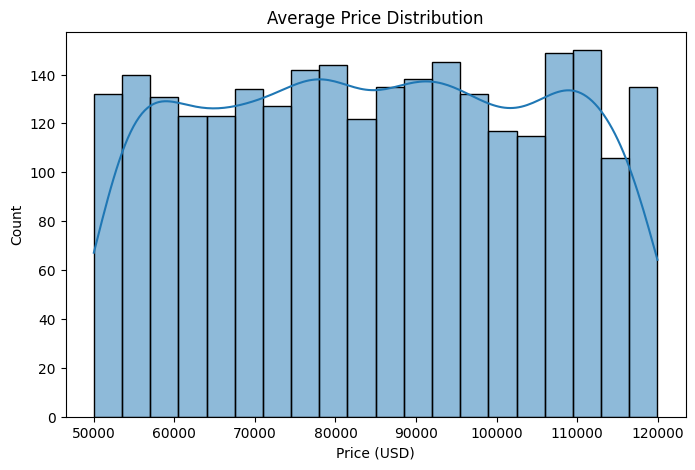

In [8]:
# Average Price Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    df["Avg_Price_USD"],
    bins=20,
    kde=True
)

plt.title("Average Price Distribution")
plt.xlabel("Price (USD)")

plt.show()

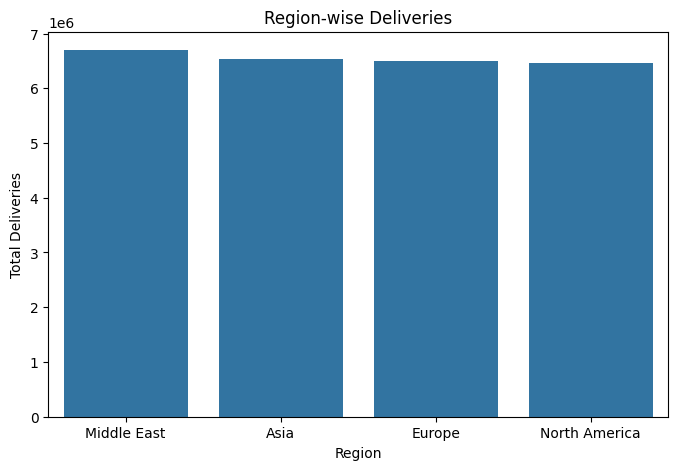

In [9]:

# Top Regions by Deliveries

region_sales = df.groupby(
    "Region"
)["Estimated_Deliveries"].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Region-wise Deliveries")
plt.xlabel("Region")
plt.ylabel("Total Deliveries")

plt.show()

In [10]:
# 6. FEATURE ENGINEERING

print("\n" + "=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

# Quarter Feature
df["Quarter"] = (
    (df["Month"] - 1) // 3
) + 1

# Price per Battery Capacity
df["Price_per_kWh"] = (
    df["Avg_Price_USD"] /
    df["Battery_Capacity_kWh"]
)

# Range Efficiency
df["Range_per_kWh"] = (
    df["Range_km"] /
    df["Battery_Capacity_kWh"]
)

print("\nNew Features Added:")
print(df[[
    "Quarter",
    "Price_per_kWh",
    "Range_per_kWh"
]].head())


FEATURE ENGINEERING

New Features Added:
   Quarter  Price_per_kWh  Range_per_kWh
0        2     773.952250       5.866667
1        1     829.408667       5.840000
2        1    1437.650244       5.853659
3        1     744.124250       5.933333
4        4     957.056500       5.508333


In [11]:
# 7. ENCODE CATEGORICAL FEATURES

print("\n" + "=" * 60)
print("ENCODING CATEGORICAL FEATURES")
print("=" * 60)

categorical_cols = [
    "Region",
    "Model",
    "Source_Type"
]

label_encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(
        df[col]
    )

    label_encoders[col] = le

print("\nCategorical Encoding Completed")


ENCODING CATEGORICAL FEATURES

Categorical Encoding Completed


In [12]:
# 8. DEFINE FEATURES & TARGET

target = "Avg_Price_USD"

X = df.drop(columns=[target])
y = df[target]

print("\nFeature Shape :", X.shape)
print("Target Shape  :", y.shape)


Feature Shape : (2640, 14)
Target Shape  : (2640,)


In [13]:
# 9. TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)


Training Data Shape : (2112, 14)
Testing Data Shape  : (528, 14)


In [14]:
# 10. MODEL BUILDING

print("\n" + "=" * 60)
print("MODEL TRAINING")
print("=" * 60)

# Initialize Models

lr_model = LinearRegression()

dt_model = DecisionTreeRegressor(
    random_state=42
)

rf_model = RandomForestRegressor(
    random_state=42
)


MODEL TRAINING


In [15]:
# Train Models

# Linear Regression
lr_model.fit(X_train, y_train)

# Decision Tree
dt_model.fit(X_train, y_train)

# Random Forest
rf_model.fit(X_train, y_train)

print("\nAll Models Trained Successfully!")


All Models Trained Successfully!


In [17]:
# 11. PREDICTIONS

lr_pred = lr_model.predict(X_test)
print("lr_pred\n",lr_pred)

dt_pred = dt_model.predict(X_test)
print("dt_pred\n",dt_pred)

rf_pred = rf_model.predict(X_test)
print("rf_pred\n",rf_pred)


lr_pred
 [ 81329.31222643  93614.03826505  65309.87467512  83743.80200299
 107643.15668463  73942.81973817  94113.14998935  59591.30643889
 100818.82073859  88640.16509585  86344.08326997  84485.7066421
 115342.48074383 101477.62924495  64711.93023668  93681.12741018
  97580.04798584 108920.94345805  88384.76441333  82365.21293128
  81028.65891686 108974.86197356 107012.17553122  70983.16453246
  76440.53801639  95234.97560805 101968.89461766  51857.62661051
  53162.0508445  105412.17903935  82239.70459637  68510.86750665
  62246.46986345 105609.04363613  69895.47393388  72401.8329473
  80666.84099727  87642.44007701  99880.13344567  52753.7793905
  75423.0374865   87047.21247357 103019.79117329  85736.30213737
  53388.55841293 104828.93704439  57081.47082433  77629.87291987
  69548.20139588  88913.04916566  98044.96602213  83233.62729878
  68720.18546183  68256.52547737  94830.07222836  98276.23953344
  62654.78144758  91281.09523791  95021.79778016  73584.3950997
  91717.5686119   52

In [19]:
# 12. MODEL EVALUATION FUNCTION

def evaluate_model(model_name, y_test, predictions):

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    mse = mean_squared_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        predictions
    )

    print("\n" + model_name)
    print("-" * 40)

    print("MAE       :", round(mae, 2))
    print("MSE       :", round(mse, 2))
    print("RMSE      :", round(rmse, 2))
    print("R2 Score  :", round(r2, 4))


In [20]:
# 13. MODEL EVALUATION

print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

evaluate_model(
    "Linear Regression",
    y_test,
    lr_pred
)

evaluate_model(
    "Decision Tree Regressor",
    y_test,
    dt_pred
)

evaluate_model(
    "Random Forest Regressor",
    y_test,
    rf_pred
)


MODEL EVALUATION

Linear Regression
----------------------------------------
MAE       : 4919.19
MSE       : 36505095.0
RMSE      : 6041.94
R2 Score  : 0.9032

Decision Tree Regressor
----------------------------------------
MAE       : 391.39
MSE       : 2393247.34
RMSE      : 1547.01
R2 Score  : 0.9937

Random Forest Regressor
----------------------------------------
MAE       : 236.11
MSE       : 463422.99
RMSE      : 680.75
R2 Score  : 0.9988



Model Comparison:
               Model  R2 Score
0  Linear Regression  0.903198
1      Decision Tree  0.993654
2      Random Forest  0.998771


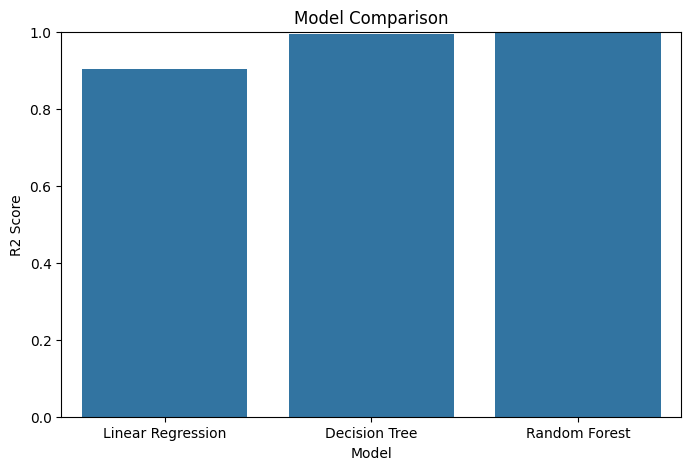

In [21]:
 #14. MODEL COMPARISON

comparison_df = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "R2 Score": [

        r2_score(y_test, lr_pred),

        r2_score(y_test, dt_pred),

        r2_score(y_test, rf_pred)
    ]
})

print("\nModel Comparison:")
print(comparison_df)

# Plot Model Comparison

plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="R2 Score"
)

plt.title("Model Comparison")
plt.ylim(0,1)

plt.show()

In [22]:
# 15. HYPERPARAMETER TUNING

print("\n" + "=" * 60)
print("HYPERPARAMETER TUNING")
print("=" * 60)

param_grid = {

    "n_estimators": [100, 200],

    "max_depth": [5, 10, None],

    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(

    estimator=RandomForestRegressor(
        random_state=42
    ),

    param_grid=param_grid,

    cv=3,

    scoring="r2",

    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("\nBest Parameters:")
print(grid_search.best_params_)


HYPERPARAMETER TUNING

Best Parameters:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}



FEATURE IMPORTANCE
                 Feature  Importance
12         Price_per_kWh    0.687569
7               Range_km    0.231668
6   Battery_Capacity_kWh    0.079770
13         Range_per_kWh    0.000565
10     Charging_Stations    0.000104
8         CO2_Saved_tons    0.000067
4   Estimated_Deliveries    0.000053
0                   Year    0.000048
5       Production_Units    0.000041
1                  Month    0.000029


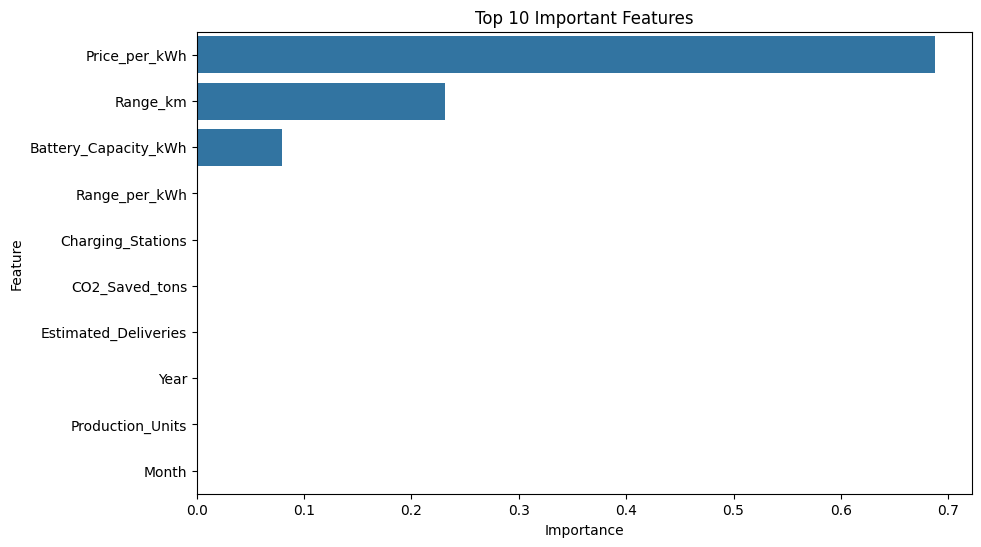

In [23]:
# 16. FEATURE IMPORTANCE

print("\n" + "=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

importance_df = pd.DataFrame({

    "Feature": X.columns,

    "Importance": best_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(10))

# Plot Feature Importance

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

In [24]:
# 17. TIME SERIES FORECASTING

print("\n" + "=" * 60)
print("TIME SERIES FORECASTING")
print("=" * 60)

forecast_data = df.groupby(
    "Year"
)["Estimated_Deliveries"].sum()

# Forecasting Model

forecast_model = ExponentialSmoothing(

    forecast_data,

    trend="add",

    seasonal=None

).fit()

# Forecast Next 5 Years

future_forecast = forecast_model.forecast(5)

print("\nFuture Forecast:")

print(future_forecast)


TIME SERIES FORECASTING

Future Forecast:
11    2.380716e+06
12    2.380434e+06
13    2.380151e+06
14    2.379869e+06
15    2.379586e+06
dtype: float64


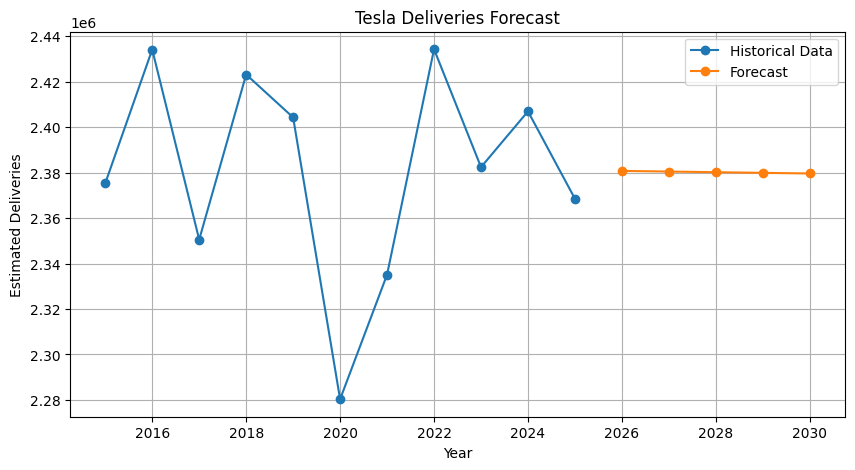

In [25]:
# Forecast Plot

plt.figure(figsize=(10,5))

plt.plot(
    forecast_data.index,
    forecast_data.values,
    label="Historical Data",
    marker='o'
)

future_years = range(

    forecast_data.index.max() + 1,

    forecast_data.index.max() + 6
)

plt.plot(
    future_years,
    future_forecast.values,
    label="Forecast",
    marker='o'
)

plt.title("Tesla Deliveries Forecast")

plt.xlabel("Year")

plt.ylabel("Estimated Deliveries")

plt.legend()

plt.grid(True)

plt.show()

In [26]:
# 18. SAVE PROCESSED DATASET

df.to_csv(
    "processed_tesla_dataset.csv",
    index=False
)

print("\nProcessed dataset saved successfully!")


Processed dataset saved successfully!


In [28]:
# 19. FINAL CONCLUSION


print("PROJECT SUMMARY\n")


print("""

Tasks Performed Successfully:

1. Data Cleaning
2. Exploratory Data Analysis
3. Feature Engineering
4. Multiple Regression Models
5. Model Comparison
6. Hyperparameter Tuning
7. Feature Importance Analysis
8. Time Series Forecasting

Models Used:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

Libraries Used:

- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Statsmodels

Project Completed Successfully.

""")

PROJECT SUMMARY



Tasks Performed Successfully:

1. Data Cleaning
2. Exploratory Data Analysis
3. Feature Engineering
4. Multiple Regression Models
5. Model Comparison
6. Hyperparameter Tuning
7. Feature Importance Analysis
8. Time Series Forecasting

Models Used:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

Libraries Used:

- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Statsmodels

Project Completed Successfully.


